In [ ]:
# Notebook d'exploration des données pour la création de features et le choix d'un modèle adapté
#
# Analyse graphique des puissances moyennes à différentes fréquences temporelles :
# - Forte saisonnalité : baisse de puissance autour du 15 août et pendant les vacances d'hiver
# - Cycle hebdomadaire marqué : 5 jours de consommation élevée, 2 jours plus faibles (week-end)
# - Consommation plus faible la nuit
# - Courbes mensuelles très similaires d'une année sur l'autre
#
# Ces observations servent de base pour la création de features adaptées au modèle, calculées dans features_engineering.py.
#
# Compte tenu du temps imparti pour le homework, j'ai choisi un modèle XGBoost, rapide à entraîner et performant sur un historique relativement limité (27 mois). 
# Le modèle est entraîné sur les données jusqu'au 2025-06-01, le test set comprenant les 4 mois suivants. 
# L'analyse exploratoire a permis d'identifier des features pertinentes, telles que week-end, nuit/jour et périodes de vacances été/hiver, qui seront utilisées par le modèle.

#


In [4]:
import pandas as pd
from forecast.utils.features_engineering import add_temporal_features,compute_mean_freq_dynamic
import matplotlib.pyplot as plt
from pathlib import Path

In [5]:
# à mettre à jour avec le fichier power.csv: 
chemin_fichier_data="/home/tiphainell/Documents/Administratif/avenir professionnel/CV/Storio Energy/forecast_assignment-main/power.csv"

#Chargement des données
data_power=pd.read_csv(chemin_fichier_data)

#Ajout de features à partir du time stamp ( year, month ...)
data_power=add_temporal_features(data_power,"start_date")
data_power



,start_date,average_imported_power_kw,year,month,day,hour,minute,week,day_name,day_of_week,is_weekend,is_winter_holiday,is_summer_holiday,15_august,season
0,2023-06-24 22:00:00+00:00,295.25,2023,6,24,22,0,25,Saturday,5,1,False,False,False,summer
1,2023-06-24 22:15:00+00:00,297.00,2023,6,24,22,15,25,Saturday,5,1,False,False,False,summer
2,2023-06-24 22:30:00+00:00,302.75,2023,6,24,22,30,25,Saturday,5,1,False,False,False,summer
3,2023-06-24 22:45:00+00:00,297.00,2023,6,24,22,45,25,Saturday,5,1,False,False,False,summer
4,2023-06-24 23:00:00+00:00,292.50,2023,6,24,23,0,25,Saturday,5,1,False,False,False,summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79387,2025-09-28 20:45:00+00:00,276.75,2025,9,28,20,45,39,Sunday,6,1,False,False,False,autumn
79388,2025-09-28 21:00:00+00:00,273.25,2025,9,28,21,0,39,Sunday,6,1,False,False,False,autumn
79389,2025-09-28 21:15:00+00:00,273.50,2025,9,28,21,15,39,Sunday,6,1,False,False,False,autumn
79390,2025-09-28 21:30:00+00:00,277.75,2025,9,28,21,30,39,Sunday,6,1,False,False,False,autumn


In [7]:
#Calcul de la puissance moyenne à differentes frequences (mensuelle, hebdomadaire, journalière ...) pur observer les tendances
# 
data_power=compute_mean_freq_dynamic(data_power)


,start_date,average_imported_power_kw,year,month,day,hour,minute,week,day_name,day_of_week,...,is_winter_holiday,is_summer_holiday,15_august,season,average_imported_power_kw_year_avg,average_imported_power_kw_month_avg,average_imported_power_kw_day_avg,average_imported_power_kw_hour_avg,average_imported_power_kw_minute_avg,average_imported_power_kw_week_avg
0,2023-06-24 22:00:00+00:00,295.25,2023,6,24,22,0,25,Saturday,5,...,False,False,False,summer,746.829159,925.730736,297.656250,298.0000,295.25,266.814904
1,2023-06-24 22:15:00+00:00,297.00,2023,6,24,22,15,25,Saturday,5,...,False,False,False,summer,746.829159,925.730736,297.656250,298.0000,297.00,266.814904
2,2023-06-24 22:30:00+00:00,302.75,2023,6,24,22,30,25,Saturday,5,...,False,False,False,summer,746.829159,925.730736,297.656250,298.0000,302.75,266.814904
3,2023-06-24 22:45:00+00:00,297.00,2023,6,24,22,45,25,Saturday,5,...,False,False,False,summer,746.829159,925.730736,297.656250,298.0000,297.00,266.814904
4,2023-06-24 23:00:00+00:00,292.50,2023,6,24,23,0,25,Saturday,5,...,False,False,False,summer,746.829159,925.730736,297.656250,297.3125,292.50,266.814904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79387,2025-09-28 20:45:00+00:00,276.75,2025,9,28,20,45,39,Sunday,6,...,False,False,False,autumn,673.303147,640.421922,264.488636,273.6875,276.75,672.666416
79388,2025-09-28 21:00:00+00:00,273.25,2025,9,28,21,0,39,Sunday,6,...,False,False,False,autumn,673.303147,640.421922,264.488636,275.0000,273.25,672.666416
79389,2025-09-28 21:15:00+00:00,273.50,2025,9,28,21,15,39,Sunday,6,...,False,False,False,autumn,673.303147,640.421922,264.488636,275.0000,273.50,672.666416
79390,2025-09-28 21:30:00+00:00,277.75,2025,9,28,21,30,39,Sunday,6,...,False,False,False,autumn,673.303147,640.421922,264.488636,275.0000,277.75,672.666416


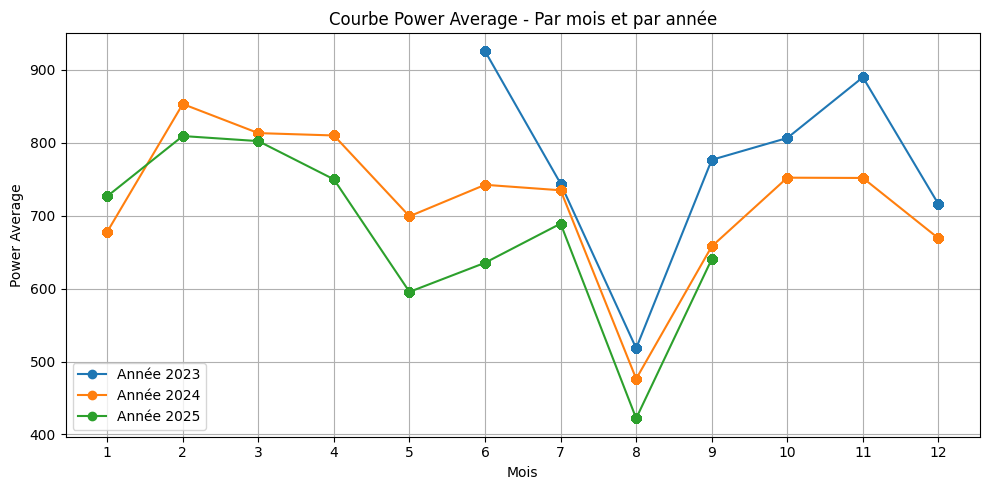

In [8]:
# Graphique de la puissance mensuelle sur les données
# 
plt.figure(figsize=(10, 5))

# Boucle sur chaque année
for year in sorted(data_power["year"].unique()):
    df_year = data_power[data_power["year"] == year].sort_values("month")
    
    plt.plot(
        df_year["month"],
        df_year["average_imported_power_kw_month_avg"],
        marker='o',
        linestyle='-',
        label=f"Année {year}"
    )

plt.title("Courbe Power monthly Average - Par mois et par année")
plt.xlabel("Mois")
plt.ylabel("Power Average")
plt.grid(True)
plt.xticks(range(1, 13))  # mois 1 à 12
plt.legend()
plt.tight_layout()
plt.show()


La puissance consommée est saisonnière avec une décroissance forte autour du 15 août. -> features à ajouter pour prendre en compte les congés d'été et le jour férié du 15 août

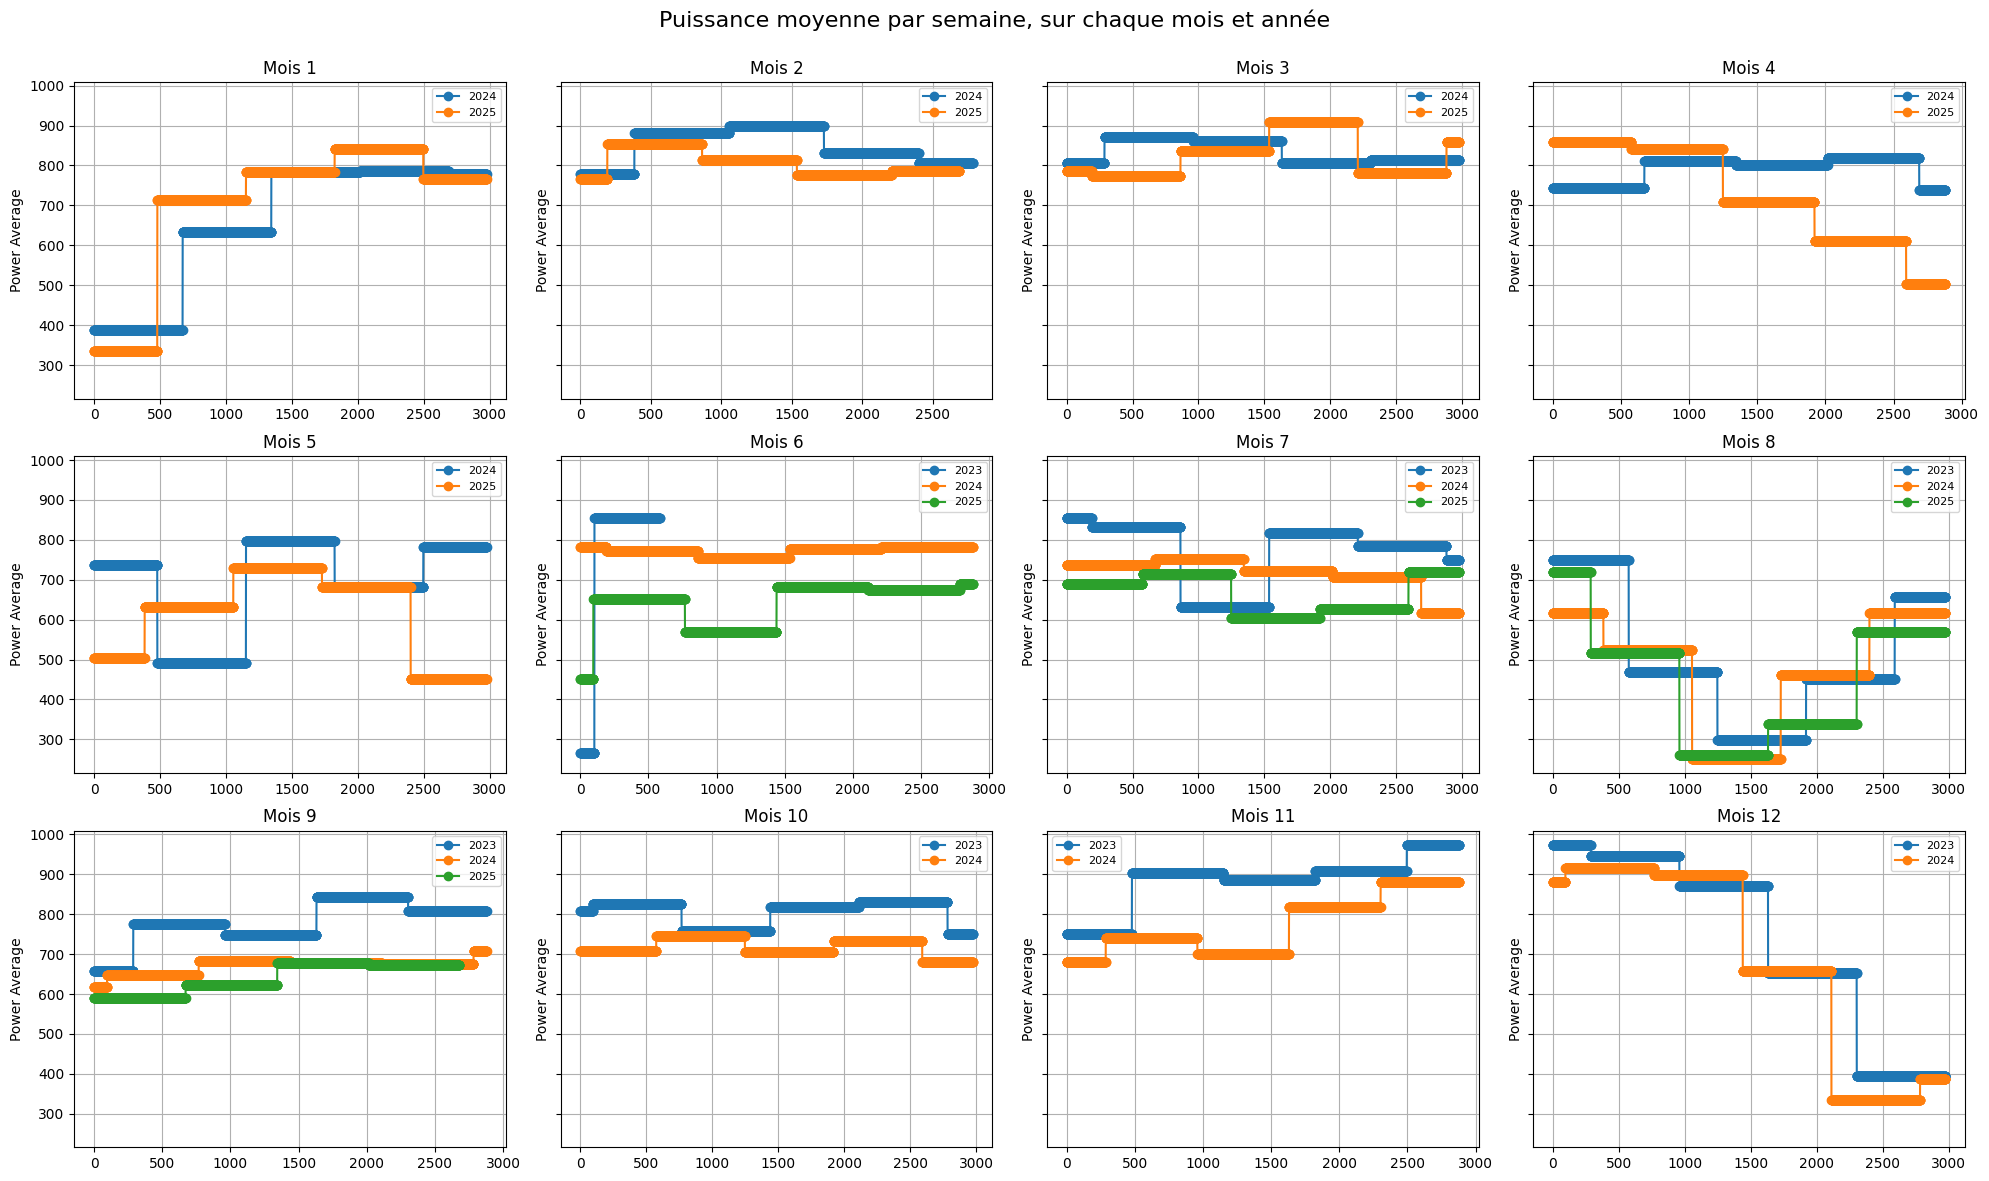

In [23]:
# Analyse de la puissance moyenne par semaine sur chaque mois
fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharey=True)  # 3 lignes, 4 colonnes

for month in range(1, 13):
    ax = axes[(month-1)//4, (month-1)%4]  # Sélection du subplot
    
    # Filtrer pour le mois courant
    df_month = data_power[data_power["month"] == month]
    
    # Boucle sur chaque année
    for year in sorted(df_month["year"].unique()):
        df_year = df_month[df_month["year"] == year].reset_index(drop=True)
        
        ax.plot(
            df_year["average_imported_power_kw_week_avg"],
            marker='o',
            linestyle='-',
            label=f"{year}"
        )
    
    ax.set_title(f"Mois {month}")
    ax.set_ylabel("Power Average")
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
fig.suptitle("Puissance moyenne par semaine, sur chaque mois et année", fontsize=16)
plt.subplots_adjust(top=0.92)
plt.show()


il y a un creux de consommation en août et au fête de fin d'année. Sinon les consommations sont assez similaires d'une année à l'autre. -> features congés fin d'année à ajouter aussi

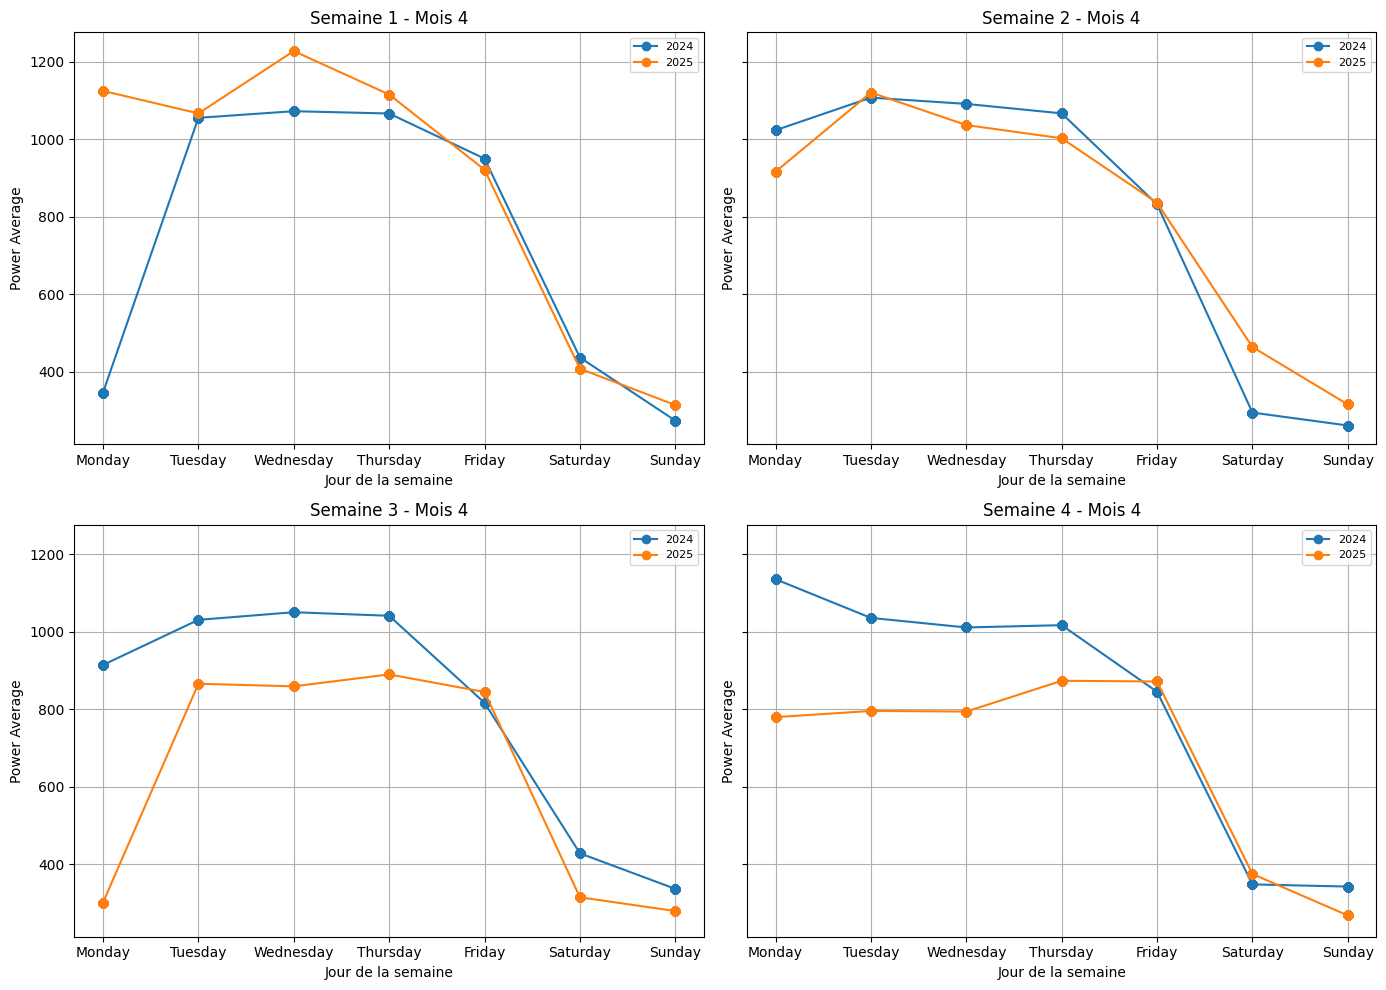

In [13]:
#Puissance moyenne par jour sur les semaines d'un mois donné
selected_month=4
    
df_month=data_power[data_power["month"] == selected_month].copy()
df_month["week_in_month"] = ((df_month["start_date"].dt.day - 1) // 7 + 1)

# Ordre des jours pour l'axe x
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Créer la figure avec 4 sous-graphes (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

for week_num in range(1, 5):
    ax = axes[(week_num-1)//2, (week_num-1)%2]
    df_week = df_month[df_month["week_in_month"] == week_num]

    for year in sorted(df_week["year"].unique()):
        df_year = df_week[df_week["year"] == year].copy()

        # Ordonner selon day_name
        df_year["day_name"] = pd.Categorical(df_year["day_name"], categories=day_order, ordered=True)
        df_year = df_year.sort_values("day_name")

        ax.plot(
            df_year["day_name"],
            df_year["average_imported_power_kw_day_avg"],
            marker='o',
            linestyle='-',
            label=f"{year}"
        )

    ax.set_title(f"Semaine {week_num} - Mois {selected_month}")
    ax.set_xlabel("Jour de la semaine")
    ax.set_ylabel("Power Average")
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

La puissance consommée baisse les weeks-ends -> features indiquant les week-ends

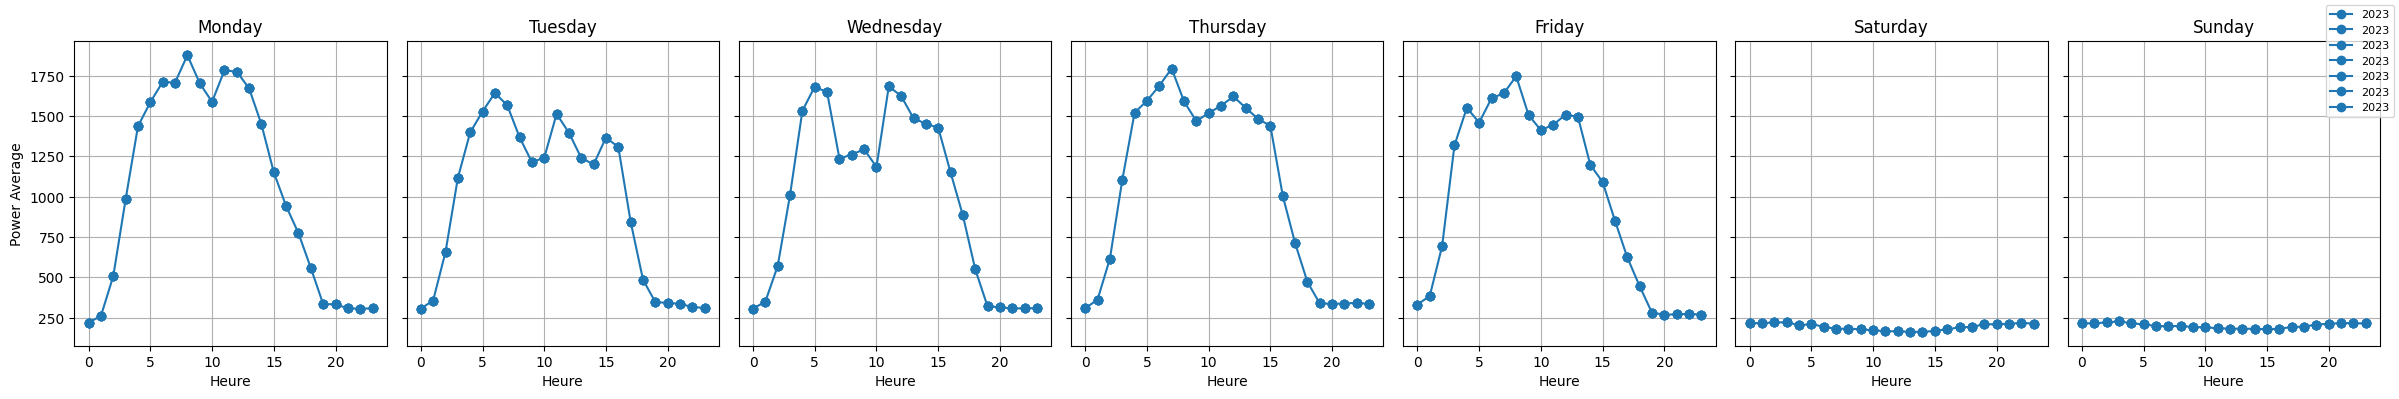

In [14]:
#Puissance moyenne par heure sur une semaine

# Assure que start_date est datetime
df = data_power.copy()
df["start_date"] = pd.to_datetime(df["start_date"])

# Choisir la semaine à visualiser (ex: semaine 2 d'un mois donné)
selected_year = 2023
selected_month = 7
selected_week = 3

# Filtrer les données
df_week = df[
    (df["year"] == selected_year) &
    (df["month"] == selected_month)
].copy()

# Ajouter colonnes nécessaires
df_week["day_name"] = df_week["start_date"].dt.day_name()
df_week["week_in_month"] = ((df_week["start_date"].dt.day - 1) // 7 + 1)
df_week["hour"] = df_week["start_date"].dt.hour

# Filtrer la semaine choisie
df_week = df_week[df_week["week_in_month"] == selected_week]

# Ordre des jours
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Créer la figure avec 7 sous-graphes (1 par jour)
fig, axes = plt.subplots(1, 7, figsize=(24, 4), sharey=True)

for i, day in enumerate(day_order):
    ax = axes[i]
    df_day = df_week[df_week["day_name"] == day]
    
    if df_day.empty:
        continue  # Pas de données pour ce jour
    
    for year in sorted(df_day["year"].unique()):
        df_year_day = df_day[df_day["year"] == year].sort_values("hour")
        
        ax.plot(
            df_year_day["hour"],
            df_year_day["average_imported_power_kw_hour_avg"],
            marker='o',
            linestyle='-',
            label=f"{year}"
        )
    
    ax.set_title(day)
    ax.set_xlabel("Heure")
    ax.grid(True)
    if i == 0:
        ax.set_ylabel("Power Average")

# Légende commune
fig.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


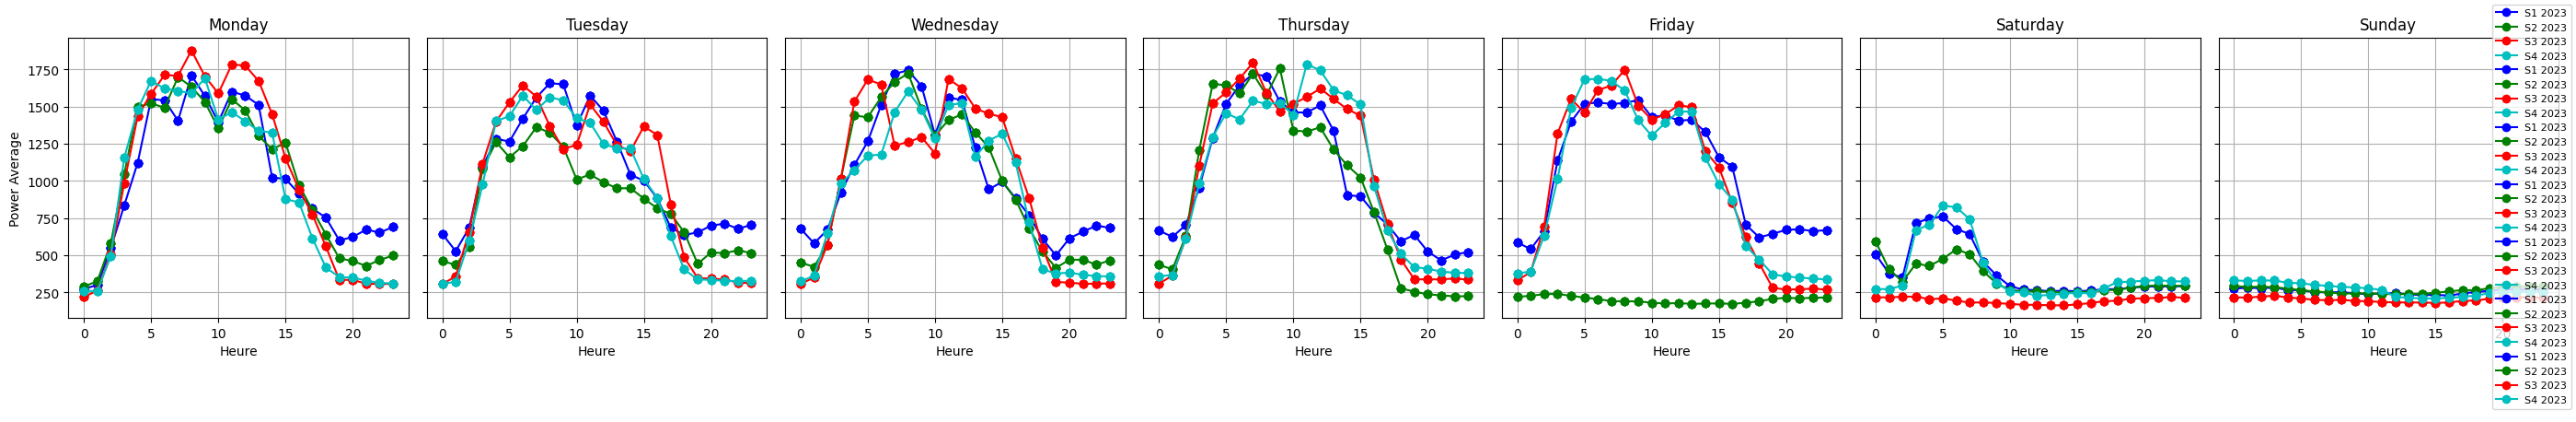

In [15]:
#Puissance moyenne par heure sur une semaine

# Assure que start_date est datetime
df = data_power.copy()
df["start_date"] = pd.to_datetime(df["start_date"])

# Choisir le mois à visualiser
selected_year = 2023
selected_month = 7

# Filtrer les données
df_month = df[
    (df["year"] == selected_year) &
    (df["month"] == selected_month)
].copy()

# Ajouter colonnes nécessaires
df_month["day_name"] = df_month["start_date"].dt.day_name()
df_month["week_in_month"] = ((df_month["start_date"].dt.day - 1) // 7 + 1)
df_month["hour"] = df_month["start_date"].dt.hour

# Ordre des jours pour les sous-graphes
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Créer la figure avec 7 sous-graphes (1 par jour)
fig, axes = plt.subplots(1, 7, figsize=(28, 4), sharey=True)

colors = ['b', 'g', 'r', 'c']  # Couleurs pour les 4 semaines

for i, day in enumerate(day_order):
    ax = axes[i]
    df_day = df_month[df_month["day_name"] == day]

    for week_num in range(1, 5):
        df_week = df_day[df_day["week_in_month"] == week_num]
        if df_week.empty:
            continue

        for year in sorted(df_week["year"].unique()):
            df_plot = df_week[df_week["year"] == year].sort_values("hour")

            ax.plot(
                df_plot["hour"],
                df_plot["average_imported_power_kw_hour_avg"],
                marker='o',
                linestyle='-',
                color=colors[week_num-1],
                label=f"S{week_num} {year}"  # semaine + année
            )

    ax.set_title(day)
    ax.set_xlabel("Heure")
    ax.grid(True)
    if i == 0:
        ax.set_ylabel("Power Average")

# Légende commune
fig.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


-> Puissance consommée diminue les weeks ends et la nuit -> features indiquant le night shift

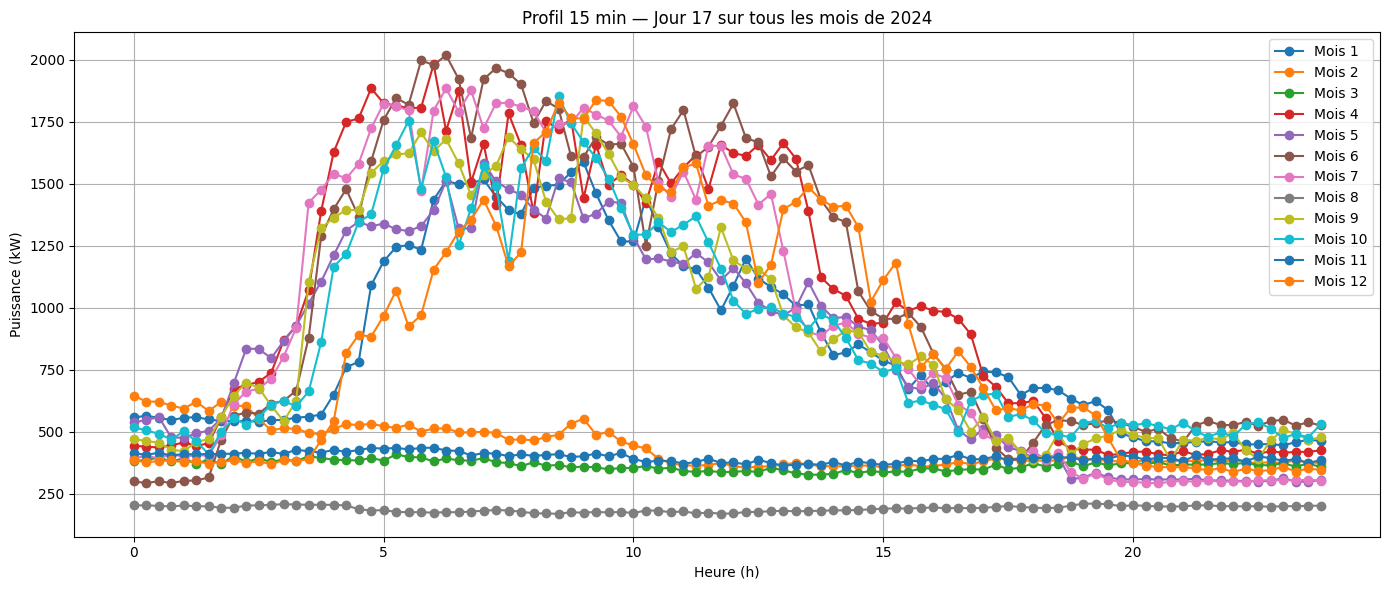

In [19]:
#Puissance moyenne sur toutes les 15 min

df = data_power.copy()
df["start_date"] = pd.to_datetime(df["start_date"])

selected_year = 2024
selected_day = 17

df_filtered = df[
    (df["year"] == selected_year) &
    (df["day"] == selected_day)
].copy()

plt.figure(figsize=(14, 6))

for month in sorted(df_filtered["month"].unique()):
    df_month = df_filtered[df_filtered["month"] == month].sort_values("start_date")

    # Convert time to fractional hours to avoid the "datetime.time" error
    x = (
        df_month["start_date"].dt.hour
        + df_month["start_date"].dt.minute / 60
        + df_month["start_date"].dt.second / 3600
    )

    plt.plot(
        x,
        df_month["average_imported_power_kw"],
        marker='o',
        linestyle='-',
        label=f"Mois {month}"
    )

plt.title(f"Profil 15 min — Jour {selected_day} sur tous les mois de {selected_year}")
plt.xlabel("Heure (h)")
plt.ylabel("Puissance (kW)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
